## Indikator penilaian


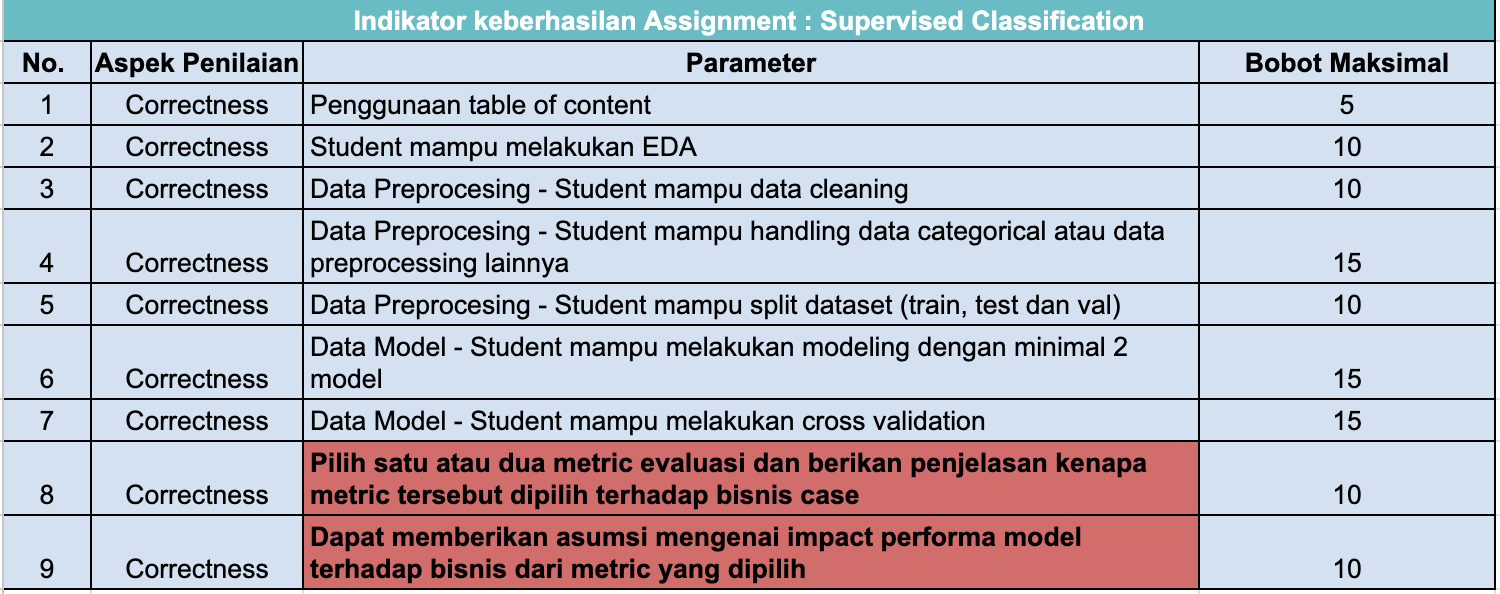

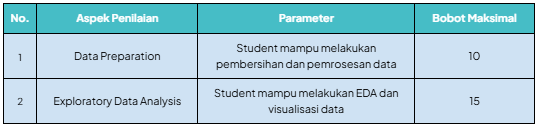

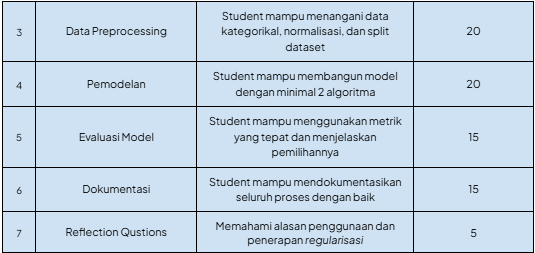

# Read Dataset

## Import Library

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import joblib
from sklearn import preprocessing
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('/content/WA_FnUseC_TelcoCustomerChurn.csv')
pd.set_option('display.max_columns',None)
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

| Column   | Description  |
|:--------:|:------------:|
| CustomerID | ID unik pelanggan |
| gender | Jenis Kelamin |
| SeniorCitizen | Pelanggan Warga Senior (T/F) |
| Partner | Apakah tinggal dengan pasangan (T/G) |
| Dependents | Apakah pelanggan memiliki tanggungan |
| tenure | lama pelanggan berlangganan dalam bulan |
| PhoneService | Layanan Telfon (T/F) |
| MultipleLines | apakah memiliki lebih dari satu sambungan telfon |
| InternetService | Jenis layanan Internet |
| OnlineSecurity | Apakah pelanggan membeli add-on keamanan Online (T/F) |
| OnlineBackup | Add-on Backup Online (T/F) |
| DeviceProtection |  Perlindungan Perangkat (T/F) |
| TechSupport | Add On dukungan Teknis (T/F) |
| StreamingTV | Add-on layanan Streaming TV (T/F) |
| StreamingMovies | Add-on Streaming film (T/F) |
| Contract | Jenis kontrak Month-to-Month, One Year, Two Year |
| PaperlessBilling | tagihan tanpa kertas (T/F) |
| PaymentMethod | metode pembayaran |
| MonthlyCharges | Total Biaya Bulanan |
| TotalCharges | Total biaya dibayar selama berlangganan |
| Churn | Target Variable Churn Tidak (T/F) |


## Data Preparation

### Check Data Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.shape

(7043, 21)

### Check Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Tidak ada Missing Values

### Check Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

Tidak ada nilai duplikat

### Correct Data Types

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

kolom TotalCharges sudah diubah menjadi numeric

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Ternyata ada Missing Values sebanyak 11 row yang disebabkan kolom pada TotalCharges terisi oleh string kosong (sehingga tidak ter-deteksi)

In [ ]:
df = df.dropna(subset=['TotalCharges'])

11 Row kolom TotalCharges sudah di drop sehingga tidak ada lagi Missing Values

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Missing Values sudah teratasi

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### Fix column Names

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [ ]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Nama kolom sudah diperbaiki menjadi lowercase dan jika ada spasi akan diganti oleh underscore

### Drop Irrelevant Column

In [ ]:
df = df.drop(columns='customerid')

In [ ]:
df.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

kolom customerid merupakan identifier sehingga tidak ada hubungan nya dengan faktor prediktif

### Class Imbalance

In [ ]:
df['churn'].value_counts(normalize=True)

,proportion
churn,
No,0.734215
Yes,0.265785


Proporsi antara kelompok yang Churn dan Tidak Churn tidak merata (50:50)

Dataset tidak balance antara proporsi churn dan tidak churn

### Define Feature & Target

In [ ]:
X = df.drop('churn', axis=1).copy()
y = df['churn']

In [ ]:
# Normalize string and map in df
df['churn'] = df['churn'].astype(str).str.strip().str.title()   # ' yes ' -> 'Yes'
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

# sinkronkan y kalau sudah didefinisikan sebelumnya
y = df['churn']

# Cek dtypes and Value Counts
print(df['churn'].dtype)
print(df['churn'].value_counts())


int64
churn
0    5163
1    1869
Name: count, dtype: int64


### Quick EDA

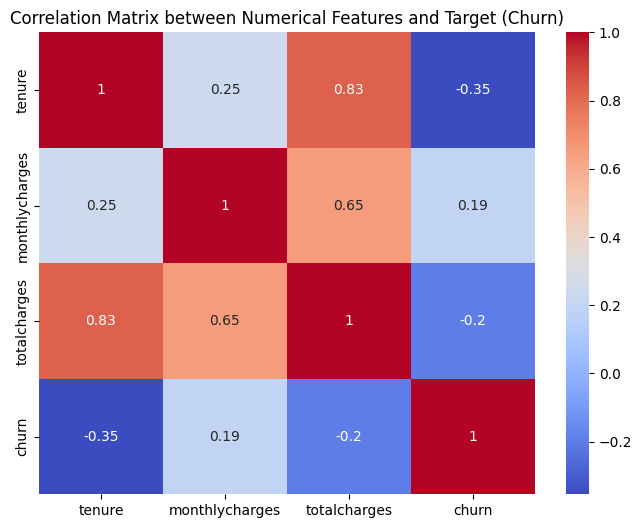

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['tenure','monthlycharges','totalcharges','churn']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix between Numerical Features and Target (Churn)")
plt.show()

Kesimpulan Matrix Correlation:  
- Tenure memiliki korelasi negatif moderat dengan churn (-0.35), menunjukan bahwa pelanggan yang baru bergabung lebih berisiko churn  
- MonthlyCharges menunjukan korelasi positif sangat lemah terhadap churn (0.19), artinya pelanggan dengan biaya bulanan lebih tinggi, sedikit lebih berisiko churn, namun pengaruhnya tidak kuat  
- TotalCharges memiliki korelasi tinggi terhadap tenure (0.83) dan korelasi lemah terhadap churn (-0.2), yang mengindikasikan bahwa pelanggan baru (totalcharges rendah) lebih mudah churn  
- secara keseluruhan, fitur numerik tidak terlalu kuat dalam memprediksi churn, sehingga informasi lebih banyak berasal dari fitur kategorikal seperti Contract, InternetService, PaymentMethod dan lain-lain

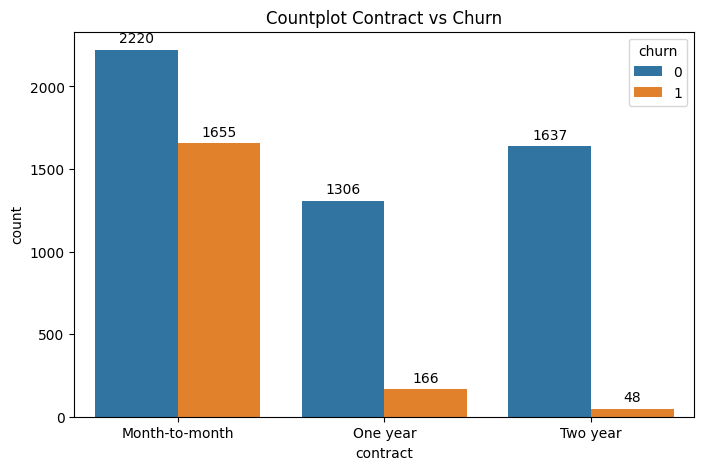

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='contract', hue='churn')

# Tambahkan angka di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Countplot Contract vs Churn")
plt.show()

Kesimpulan Grafik Countplot:  
- Pelanggan dengan kontrak Month-to-month memiliki tingkat churn tinggi  
- Kontrak One year menunjukan churn yang jauh lebih kecil  
- Kontrak Two year memiliki churn paling rendah

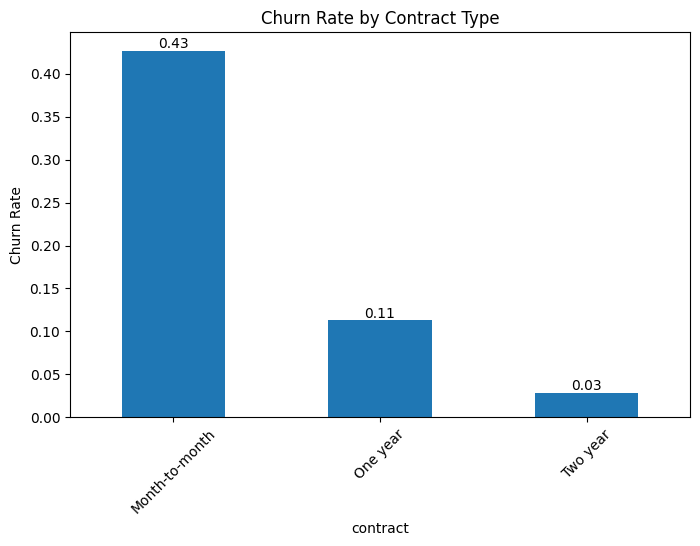

In [ ]:
plt.figure(figsize=(8,5))
ax = df.groupby('contract')['churn'].mean().plot(kind='bar')

# Tambahkan angka di atas bar
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.2f}",
                (p.get_x() + p.get_width() / 2, value),
                ha='center', va='bottom', fontsize=10)

plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=45)
plt.show()

Berdasarkan barplot, jenis contract Month-to-month adalah jenis contract yang memiliki tingkat churn paling tinggi, One Year tingkat churn rendah, dan two year yang paling rendah

### Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Dataset telah dibagi menjadi 80% train 20% test

# Train

## Data Preprocessing

In [ ]:
# Define Numerical and Categorical Column
numerical_column = ['tenure','monthlycharges','totalcharges']
categorical_column = [c for c in X_train.columns if c not in numerical_column]

print("Numerical :", numerical_column)
print("Categorical :", categorical_column [:10])

Numerical : ['tenure', 'monthlycharges', 'totalcharges']
Categorical : ['gender', 'seniorcitizen', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection']


Pemisahan kolom kategorikal dan numerikal telah dilakukan

## Build Models

In [ ]:
# Build preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_column),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_column)
    ],
    remainder='drop'
)

# Define models
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'xGBoost': XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

Fitur numerik -> distandarisasi  
Fitur kategorikal -> di-encode OHE  
Model Logistic Regression, Random Forest, XGBoost dilatih menggunakan hasil data Preprocessing tersebut

## Cross Validation (5-Fold CV per Models)

In [ ]:
from sklearn.model_selection import cross_val_score

cv_summary = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('clf', estimator)
    ])

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    cv_summary[name] = (cv_scores.mean(), cv_scores.std())

    print(f"{name}: CV ROC AUC mean = {cv_scores.mean():.4f}, std = {cv_scores.std():.4f}")


LogisticRegression: CV ROC AUC mean = 0.8459, std = 0.0189
RandomForest: CV ROC AUC mean = 0.8199, std = 0.0135
xGBoost: CV ROC AUC mean = 0.8153, std = 0.0127


In [ ]:
# Convert to DataFrame

cv_df = pd.DataFrame.from_dict(cv_summary, orient='index', columns=['CV ROC AUC mean', 'std'])

# Reset index
cv_df = cv_df.reset_index().rename(columns={'index': 'Model'})

display(cv_df)

,Model,CV ROC AUC mean,std
0,LogisticRegression,0.845932,0.018943
1,RandomForest,0.819938,0.013488
2,xGBoost,0.815266,0.012701


## Model Evaluation

In [ ]:
results = []
roc_curves = {}

for name, estimator in models.items():
    print(f"\n--- Training & Evaluating {name} ---")

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('clf', estimator)
    ])

    pipe.fit(X_train, y_train)
    joblib.dump(pipe, f'pipeline_{name}.joblib')

    y_pred = pipe.predict(X_test)

    # probability for ROC
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except:
        y_proba = pipe.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC AUC: {auc:.4f}")

    # store results
    results.append({
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': auc
    })

    # save ROC data
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_curves[name] = (fpr, tpr, auc)


--- Training & Evaluating LogisticRegression ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Confusion Matrix:
 [[917 116]
 [159 215]]
Accuracy: 0.8045 | Precision: 0.6495 | Recall: 0.5749 | F1: 0.6099 | ROC AUC: 0.8359

--- Training & Evaluating RandomForest ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407

Confusion Matrix:
 [[916 117]
 [187 187]]
Accuracy: 0.7839 | Precision: 0.6151 | Recall: 0.5000 | F1: 0.5516 | ROC AUC: 0.815

In [ ]:
result_model_df = pd.DataFrame(results)

# Sort Values by ROC AUC
result_model_df = result_model_df.sort_values(by='roc_auc', ascending=False)
print("\n=== Summary Results Table ===")
display(result_model_df)


=== Summary Results Table ===


,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.804549,0.649547,0.574866,0.609929,0.835934
1,RandomForest,0.783937,0.615132,0.500000,0.551622,0.815807
2,xGBoost,0.766880,0.564972,0.534759,0.549451,0.801879


## Model Comparison & ROC Curve Plot

                model  accuracy  precision    recall        f1   roc_auc
0  LogisticRegression  0.804549   0.649547  0.574866  0.609929  0.835934
1        RandomForest  0.783937   0.615132  0.500000  0.551622  0.815807
2             xGBoost  0.766880   0.564972  0.534759  0.549451  0.801879


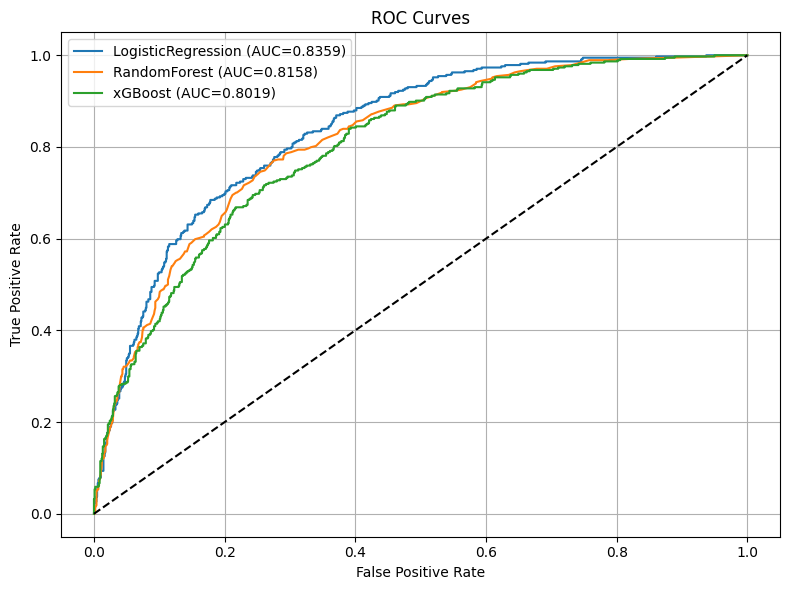

In [ ]:
results_df = pd.DataFrame(results).sort_values(by='roc_auc', ascending=False)
print(results_df)

results_df.to_csv("model_comparison_results.csv", index=False)

# ROC PLOT
plt.figure(figsize=(8,6))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_comparison.png')
plt.show()

Berdasarkan hasil evaluasi pada test, Logistic Regression menunjukkan performa terbaik dengan nilai ROC AUC = 0.8359, diikuti oleh Random Forest (0.8158), dan XGBoost (0.8019). Hal ini menunjukkan bahwa Logistic Regression adalah model yang paling konsisten dalam membedakan pelanggan yang churn dan tidak churn pada dataset ini.  

Jika dilihat dari kurva ROC, ketiga model memiliki pola yang mirip, namun area di bawah kurva Logistic Regression sedikit lebih luas. Ini mengindikasikan bahwa model tersebut memiliki kemampuan prediksi yang lebih stabil dan lebih baik dalam mengidentifikasi pelanggan berisiko churn

## Pilih satu atau dua metric evaluasi dan berikan penjelasan kenapa metric tersebut dipilih terhadap business case

Saya pilih metrik AUC dan Recall, dikarenakan keduanya paling relevan untuk kasus churn. AUC digunakan untuk menilai kemampuan model membedakan pelanggan churn dan tidak churn secara menyeluruh. Recall penting, karena dalam konteks bisnis, lebih berbahaya jika model gagal mendeteksi pelanggan yang benar benar akan churn (false negative), sehingga fokus utamanya adalah menangkap sebanyak mungkin pelanggan yang berisiko churn

## Dapat memberikan asumsi mengenai impact performa model terhadap bisnis dari metric yang dipilih

Dengan recall yang baik, model mampu mendeteksi lebih banyak pelanggan yang berpotensi churn, sehingga tim bisnis dapat melakukan intervensi lebih efektif (melakukan pencegahan), seperti memberikan penawaran retensi atau diskon khusus. Sementara AUC yang tinggi memastikan keputusan tersebut lebih tepat sasaran, sehingga biaya retensi tidak terbuang sia-sia untuk pelanggan yang sebenarnya masih setia (tidak akan churn)

## Reflection Question: Memahami alasan penggunaan dan penerapan regularisasi

Regularisasi digunakan untuk mencegah overfitting, dengan cara mengontrol besarnya koefesien model. Hal ini penting, mengapa? karena ketika model memiliki banyak fitur hasil encoding, model tidak belajar pola yang terlalu spesifik dari data latih. Dengan regularisasi, model jadi lebih stabil dan memiliki generalisasi yang lebih baik pada data baru.

# Kesimpulan Akhir

Berdasarkan hasil evaluasi, Logistic Regression dipilih sebagai model terbaik karena memiliki skor ROC AUC tertinggi dan performa yang paling stabil pada cross validation. Model ini menunjukkan kemampuan prediksi yang baik dalam mengidentifikasi pelanggan berisiko churn, sehingga dapat membantu perusahaan merancang strategi retensi yang lebih tepat sasaran dan efisien dalam penggunaan biaya pemasaran. Selain itu, hasil model dapat digunakan untuk memberikan penawaran khusus atau program diskon kepada pelanggan yang berpotensi churn, sehingga meningkatkan peluang retensi secara keseluruhan.